# Разработка пользовательских функций

По желанию пользователь может разрабатывать и тестировать новые алгоритмы и функции.

Для этого необходимо создать класс-функцию наследующую от соответсвующего базового класса-функции (в зависимости от поставленной задачи)

В Генезис реализованы следующие базовые классы:

| Базовый Класс-функция | Описание |
|--------------------|----------|
| [`MetricBase`](405_base_classes.qmd#metricbase) | Метрики |
| [`StateBase`](405_base_classes.qmd#statebase) | Состояние |
| [`BestPointsBase`](405_base_classes.qmd#bestpointsbase) | Алгоритм BLP |
| [`MCLPBase`](405_base_classes.qmd#mclpbase) | Алгоритм MCLP |
| [`StopCaseBase`](405_base_classes.qmd#stopcasebase) | Функция остановки |
| [`PointSelectorBase`](405_base_classes.qmd#pointselectorbase) | Селектор новых узлов |
| [`LSCPBase`](405_base_classes.qmd#lscpbase) | Алгоритм LSCP |

## Пример реализации пользовательского алгоритма BLP

В качестве примера рассмотри создание алгоритма поиска лучшего узла графа методом рекурсивного деления области на квадраты.

Логика алгоритма будет следующая:

Дан граф улично-дорожной сети в формате `networkx.MultiDiGraph`, веса ребер определены полем `travel_time` и представляют время следования по участку дороги в минутах. 

Алгоритм:

1. Граф проецируется в локальную систему координат при помощи `osmnx.project_graph`
2. Определяется основной прямоугольник `P` в который вписаны все узлы графа
3. Основной прямоугольник разбивается на некоторое количество квадратов меньшего размера. Размер стороны квадратов определется как половина наименьшего измерения прямоугольника `P`
4. В пределах каждого из меньших квадратов определяется `n` узлов, для каждого из них при помощи `genesis.Best_points.NodeMetric` определяется значение метрики времени среднего времени прибытия `genesis.metrics.ArrivalTime`
5. Выбирается квадрат в пределах которого находится узел с наилучшей метрикой
6. Если в пределах квадрата содержится больше узлов чем некоторое минимальное значение `n_min_count` задаваемое как гиперпараметр алгоритма, то шаги 4,5,6 повторяются
7. Алгоритм возвращает узел с лучшей метрикой

Алгоритм должен реализован как наследник класса `genesis.core.BestPointsBase` и реализует соответсвующий интерфейс.

Подключение необходимых библиотек

In [33]:
import networkx as nx
import numpy as np
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely

Загрузка исходных данных

In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ населенного пункта
borders = gpd.read_file('data/kemerovo/borders.gpkg')

Реализация алгоритма

In [ ]:
import random
import math
from genesis.core import BestPointsBase, StateBase, MetricBase
from genesis.best_points import NodeMetric
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState


class BestNodeSquareZoom(BestPointsBase):
    """
    Поиск лучшего узла графа методом рекурсивного деления области на квадраты.
    1. Проекция графа в локальную систему координат.
    2. Определение главного прямоугольника, в который вписаны узлы графа.
    3. Разбиение прямоугольника на квадраты со стороной min(width, height)/2.
    4. В каждом квадрате случайная выборка до n узлов и вычисление метрики.
    5. Выбор квадрата с узлом наилучшей метрики и рекурсия, пока количество узлов в квадрате не <= n_min_count.
    """
    def __init__(self, state_function: StateBase,
                metric_function: MetricBase,
                n_samples: int = 10,
                n_min_count: int = 5,
                **kwargs):
        """
        `state_function`: StateBase — функция расчета состояния окружения.
        `metric_function`: MetricBase — функция расчета метрики.
        `n_samples`: int — максимальное число узлов для оценки в каждом квадрате.
        `n_min_count`: int — минимальное число узлов для останова рекурсии.
        """
        self.n_samples = n_samples
        self.n_min_count = n_min_count
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self, env: nx.Graph,
                area=None, 
                start_point: int = None,
                points_list: set = None,
                **kwargs) -> tuple[int | None, float | None]:
        """
        `env`: MultiDiGraph — граф улично-дорожной сети.
        `area`: pandas.Series — маска узлов графа для расчёта доступности (см. NodeMetric).
        `start_point`: не используется.
        `points_list`: set — начальный набор узлов-кандидатов.
        Возвращает `(best_node, best_metric)`.
        """
        # Подготовка исходных узлов
        if points_list is None:
            current_nodes = list(env.nodes())
        else:
            current_nodes = list(points_list)
        # Проекция графа
        # Проекция графа только если он в географической системе координат
        if env.graph['crs'] == 'epsg:4326':
            G = ox.project_graph(env)
        else:
            G = env
        node_metric_fn = NodeMetric(self.state_function, self.metric_function)
        best_node = None
        best_metric = None

        level = 1
        best_squares = []
        while True:
            # Ограничиваем текущие узлы маской area, если задана
            if area is not None:
                current_nodes = [u for u in current_nodes if area.get(u, False)]
            if not current_nodes:
                return None, None
            # Координаты узлов
            xs = [G.nodes[u]['x'] for u in current_nodes]
            ys = [G.nodes[u]['y'] for u in current_nodes]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            dx, dy = x_max - x_min, y_max - y_min
            size = min(dx, dy) / 2
            # Создание квадратов
            nx_squares = int(math.ceil(dx / size))
            ny_squares = int(math.ceil(dy / size))
            squares = []
            for i in range(nx_squares):
                for j in range(ny_squares):
                    x0, y0 = x_min + i * size, y_min + j * size
                    squares.append((x0, y0, x0 + size, y0 + size))
            # Оценка квадратов
            best_node_sq = None
            best_metric_sq = None
            best_square_nodes = None
            square = 1
            best_squares_in_square = None
            for x0, y0, x1, y1 in squares:
                # Узлы в квадрате
                nodes_sq = [u for u in current_nodes if x0 <= G.nodes[u]['x'] <= x1 and y0 <= G.nodes[u]['y'] <= y1]
                if not nodes_sq:
                    continue
                # Выборка узлов
                if len(nodes_sq) > self.n_samples:
                    sample = random.sample(nodes_sq, self.n_samples)
                else:
                    sample = nodes_sq
                # Оценка узлов
                for u in sample:
                    node_metric = node_metric_fn(env=G, node=u, area=area, **kwargs)
                    if node_metric is None:
                        continue
                    if best_metric_sq is None or self.metric_function.compare(node_metric, best_metric_sq) == node_metric:
                        best_metric_sq = node_metric
                        best_node_sq = u
                        best_square_nodes = nodes_sq
                        best_squares_in_square = (x0, y0, x1, y1)
                print(f'square {square} - {best_node_sq}, {best_metric_sq}')
                square += 1
            best_squares.append(best_squares_in_square)
            if best_node_sq is None:
                break
            best_node, best_metric = best_node_sq, best_metric_sq
            # Проверка условия останова
            if len(best_square_nodes) <= self.n_min_count:
                break
            # Переход к узлам лучшего квадрата
            current_nodes = best_square_nodes
            # Печать результата
            print(f'level {level} - {best_node}, {best_metric}')
            level += 1

        return best_node, best_metric, best_squares

:::{.callout-important}

В данном случае функционал алгоритма был расширен за счет добавления в перечень возвращаемых переменных списка квадратов в пределах которых обнаружен лучший узел.

Это сделано для визуализации хода расчета и отладки. В готовых решениях изменение перечня возвращаемых аргументов строго воспрещено логикой и будет приводить к ошибке при использовании алгоритма в составе гибридных решений.

:::

square 1 - 10731791184, 16.59093751929235
square 2 - 10731791184, 16.59093751929235
square 3 - 10731791184, 16.59093751929235
square 4 - 10731791184, 16.59093751929235
square 5 - 10731791184, 16.59093751929235
square 6 - 10731791184, 16.59093751929235
level 1 - 10731791184, 16.59093751929235
square 1 - 775453060, 28.338463824106277
square 2 - 5084974091, 22.200625880473066
square 3 - 390615908, 20.29736344874703
square 4 - 1432526171, 15.506545978847514
square 5 - 1432526171, 15.506545978847514
level 2 - 1432526171, 15.506545978847514
square 1 - 2537678942, 20.263088896759616
square 2 - 10941191746, 18.7696212272216
square 3 - 10595884338, 16.92572271200879
square 4 - 12200773782, 15.484790316849084
square 5 - 12200773782, 15.484790316849084
level 3 - 12200773782, 15.484790316849084
square 1 - 1515032972, 15.219339346913326
square 2 - 1515032972, 15.219339346913326
square 3 - 1515032972, 15.219339346913326
square 4 - 1515032972, 15.219339346913326
square 5 - 1515032972, 15.219339346913

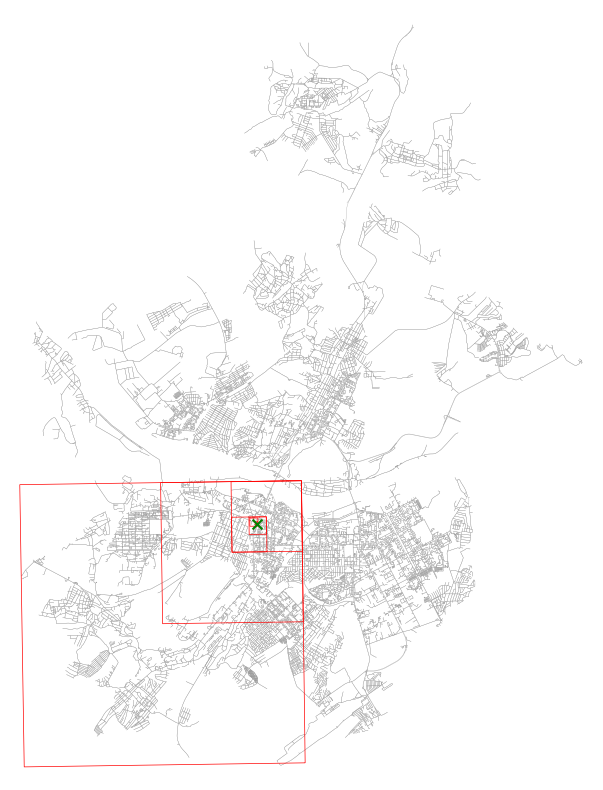

In [38]:
# Инициализация алгоритма
blp = BestNodeSquareZoom(
    state_function  = FirstArrivalUnitState(),
    metric_function = ArrivalTime(),
    n_samples       = 10,
    n_min_count     = 10,
    )

# Расчет лучшего размещения
best_node, best_metric, best_squares = blp(G)


# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')


# Визуализация ГДС с оптимальной точкой размещения и квадратами последовательного приближения
geometry = [shapely.geometry.box(x0, y0, x1, y1) for x0, y0, x1, y1 in best_squares]

boxes = gpd.GeoDataFrame(geometry, columns=['geometry'], crs=ox.project_graph(G).graph['crs'])
boxes = ox.projection.project_gdf(boxes, to_latlong=True)

fig, ax = plt.subplots(figsize=(10, 10))
ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
boxes.boundary.plot(ax=ax, color='red', linewidth=0.5)
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='g', marker='x', 
                                                       markersize=50, zorder=10)
plt.show()

Проверка расчета для метрики ИП-10.

Дополнительно используем функцию `genesis.untils.timing` для вывода времени ваыполнения алгоритма.

square 1 - 10560741809, 25.791531303342328
square 2 - 10560741809, 25.791531303342328
square 3 - 10560741809, 25.791531303342328
square 4 - 12240751488, 32.86162656241397
square 5 - 12240751488, 32.86162656241397
square 6 - 12240751488, 32.86162656241397
level 1 - 12240751488, 32.86162656241397
square 1 - 7005955871, 8.264963383073619
square 2 - 12333912009, 27.212157920819337
square 3 - 12240751495, 32.87814547657067
square 4 - 12240751495, 32.87814547657067
square 5 - 12240751495, 32.87814547657067
square 6 - 12240751495, 32.87814547657067
level 2 - 12240751495, 32.87814547657067
square 1 - 10669461560, 31.308848631683276
square 2 - 10669461560, 31.308848631683276
square 3 - 5619329469, 31.319861241121085
square 4 - 5619329469, 31.319861241121085
square 5 - 5619329469, 31.319861241121085
square 6 - 5619329469, 31.319861241121085
level 3 - 5619329469, 31.319861241121085
square 1 - 9107440367, 33.01580309454325
square 2 - 9107440367, 33.01580309454325
square 3 - 9107440367, 33.01580309

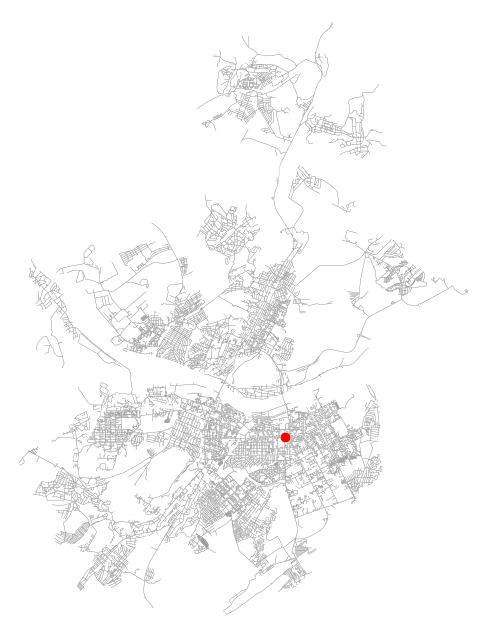

In [39]:
# Использование алгоритма Обезьяньего поиска
from genesis.metrics import CoverIndex
from genesis.utils import timing

blp = timing(BestNodeSquareZoom(
    state_function  = FirstArrivalUnitState(),
    metric_function = CoverIndex(),
    n_samples       = 10,
    n_min_count     = 5,
    ))

# Расчет лучшего размещения
best_node, best_metric, _ = blp(env=G)

# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Визуализация ГДС с оптимальной точкой размещения
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='red');

Аналогичным образом можно разрабатывать и иные решения наследующие базовые классы и в дальнейшем эффективно их применять.


:::{.callout-note}

Основным условием эффективной разработки является строгое соблюдение интерфейса базового класса.

:::

## Пример реализации пользовательской метрики

Пользователь имеет возможность реализации собственных функций расчета метрик.

Ниже приведен пример реализации метрики оценивающей неравномерность нагрузки на ПСЧ.

Для этого будем оценивать значение стандартного отклонения количества прикрываемых каждым подразделением.

Стандартное отклонение рассчитывается по формуле:

$$\sigma = \sqrt{\frac{\sum(x - \mu)^2}{N}}$$

где:
- $\sigma$ - стандартное отклонение
- $x$ - значение в выборке 
- $\mu$ - среднее арифметическое выборки
- $N$ - размер выборки

In [47]:
import pandas as pd


class StdIndex(MetricBase):

    def __init__(self, comp_func:callable=min) -> None:
        '''
        Функция comp_func отвечает за сравнение значений полученных при помощи метрики.
        '''

        super().__init__(comp_func)

    def __call__(self, state, area=None):
        '''
        `state` (`состояние`): pd.Series
            В данном случае это будет серия идентификаторов ближайших подразделений.
            получаемая в результате работы функций расчета состояния.

                times, nearest = FirstArrivalUnitState()(env=G, area=area)

        `area`: pd.Series
            Серия данных содержащих маску точек которые должны быть учтены при расчете метрики.
        '''
        
        if not isinstance(state, (list, pd.Series)):
            raise TypeError(
                f"Аргумент times может быть только типа list или pd.Series"
                f" Имеется {type(state)}"
                )

        # Отбор узлов по area (списку узлов которые следует учесть в расчете)
        if not area is None:
            if isinstance(state, pd.Series):
                state_c = state.loc[area]
            else:
                state_c = [x for x in state if x in area]
        else:
            state_c = state

        # Расчет количества узлов прикрываемых каждым подразделением
        values = state.value_counts()
        return values.std()


# Проверка работы метрики
g_nodes = list(G.nodes)
start_points = {
    g_nodes[1000]: 'псч 1',
    g_nodes[2000]: 'псч 2',
    g_nodes[3000]: 'псч 3',
    g_nodes[4000]: 'псч 4',
}

times, nearest = FirstArrivalUnitState()(env=G, points=start_points)

print("Метрика неравномерности нагрузки на ПСЧ:", StdIndex()(nearest))
print('Количество прикрываемых ПСЧ узлов (нагрузка):')
print(nearest.value_counts())

Метрика неравномерности нагрузки на ПСЧ: 5333.579621917473
Количество прикрываемых ПСЧ узлов (нагрузка):
nearest
псч 4    12418
псч 3     3171
псч 2     1623
псч 1      949
Name: count, dtype: int64


Чем меньше данный показатель, тем лучше - это значит, что нагрузка на подразделения распределена равномерно. Рассмотрим несколько вариантов расстановки.

In [49]:
print('Вариант расстановки №1')
start_points = {
    g_nodes[1000]: 'псч 1',
    g_nodes[2000]: 'псч 2',
    g_nodes[3000]: 'псч 3',
    g_nodes[4000]: 'псч 4',
}
times, nearest = FirstArrivalUnitState()(env=G, points=start_points)
print("Неравномерность нагрузки на ПСЧ:", StdIndex()(nearest))

print('Вариант расстановки №2')
start_points = {
    g_nodes[1500]: 'псч 1',
    g_nodes[2500]: 'псч 2',
    g_nodes[3500]: 'псч 3',
    g_nodes[4500]: 'псч 4',
}
times, nearest = FirstArrivalUnitState()(env=G, points=start_points)
print("Неравномерность нагрузки на ПСЧ:", StdIndex()(nearest))

print('Вариант расстановки №3')
start_points = {
    g_nodes[5000]: 'псч 1',
    g_nodes[6000]: 'псч 2',
    g_nodes[7000]: 'псч 3',
    g_nodes[8000]: 'псч 4',
}
times, nearest = FirstArrivalUnitState()(env=G, points=start_points)
print("Неравномерность нагрузки на ПСЧ:", StdIndex()(nearest))

print('Вариант расстановки №4')
start_points = {
    g_nodes[1000]: 'псч 1',
    g_nodes[2000]: 'псч 2',
    g_nodes[10000]: 'псч 3',
    g_nodes[15000]: 'псч 4',
}
times, nearest = FirstArrivalUnitState()(env=G, points=start_points)
print("Неравномерность нагрузки на ПСЧ:", StdIndex()(nearest))

Вариант расстановки №1
Неравномерность нагрузки на ПСЧ: 5333.579621917473
Вариант расстановки №2
Неравномерность нагрузки на ПСЧ: 2694.043599622446
Вариант расстановки №3
Неравномерность нагрузки на ПСЧ: 4038.7765783712275
Вариант расстановки №4
Неравномерность нагрузки на ПСЧ: 3621.3004455121736


Видно, что с точки зрения равномерности нагрузки наилучшим вариантом является **Вариант №2**.

## Модификация существующего алгоритма MCLP

Однако, логика алгоритмов Генезис подразумевает передачи в функции метрик только серии времен `times`. Серия идентификаторов ближайших подразделений `nearest` не реализована, поэтому для ее корректного использования необходимо также внести изменения и в алгоритм расчета.

Сделаем это на примере Генетического алгоритма. Для модификации достаточно изменить функцию расчета приспособленности `_fit_function`.

In [ ]:
from genesis.core import MCLPBase, PointSelectorBase
from genesis.tools import list_dict_concat


class BestNodesGA2(MCLPBase):

    def __init__(self,
                 state_function     :StateBase,
                 metric_function    :MetricBase,
                 node_selector      :PointSelectorBase,
                 population_size    :int = 25,
                 epochs             :int = 50,
                 mutation_rate      :float = 0.5,
                 elite_size         :int = 0,
                 appr_val_in_area   :float = 0,
                 mutation_max_count :int | float = 1,
                 bad_val_in_area    :int = 1000,
                 epoch_end_function :callable = None,
                 stop_case_function :callable = None,
                 **kwargs) -> None:

        if population_size <= 5:
            raise ValueError('Размер популяции должен быть > 0, так же не рекомендуется использовать размер популяции < 5')
        if epochs  <=  0:
            raise ValueError('Количество эпох должно быть > 0')
        if mutation_max_count  <=  0:
            raise ValueError('Максимальное количество единиц мутации должно быть > 0')
        if mutation_rate <0 or mutation_rate > 1:
            raise ValueError('Вероятность мутации должна лежать в диапазоне (0,1)')
        if appr_val_in_area <0 or appr_val_in_area > 1:
            raise ValueError('Доля узлов графа в пределах area, должна лежать в диапазоне (0,1)')
        if elite_size < 0:
            raise ValueError('Количество особей в элитной группе должно быть >= 0')
        
        self.population_size = population_size
        self.epochs = epochs
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size
        self.appr_val_in_area = appr_val_in_area
        self.mutation_max_count = mutation_max_count
        self.bad_val_in_area = bad_val_in_area
        self.epoch_end_function = epoch_end_function
        self.stop_case_function = stop_case_function
        self.node_selector = node_selector
        super().__init__(state_function, metric_function, **kwargs)


# Достаточно внести изменения в функцию расчета приспособленности
    def _fit_function(self, env, nodes, area=None, **kwargs):
        '''
        Расчет функции приспособленности
        '''
        # 2.1. Расчет состояния
        times, nearest = self.state_function(env=env, points=nodes, area=area, **kwargs)

        if not area is None:
            appr_nodes_count = area.sum() * self.appr_val_in_area
            # Проверка на обеспечение требуемой степени прикрытия территории
            if len(nearest) < appr_nodes_count:
                print('Расстановка не обеспечивает требуемую степень прикрытия территории area')
                return self.bad_val_in_area

        # 2.2. Расчет стартовой метрики состояния и определение стартового размещения
# Расчет метрики неравномерности нагрузки на ПСЧ
# Здесь заменяем `times` на `nearest` 
        best_metric = self.metric_function(nearest, **kwargs)

        return best_metric

    def _mutate(self, env, new_dynamic_nodes, area):
        '''
        Мутация особи
        '''
        if self.mutation_max_count >= 1:
            mutation_count = self.mutation_max_count
        elif self.mutation_max_count > 0 and self.mutation_max_count < 1:
            mutation_count = int(len(new_dynamic_nodes) * self.mutation_max_count)
        else:
            mutation_count = len(new_dynamic_nodes)
        if mutation_count == 0:
            mutation_count = 1
        for _ in range(mutation_count):
            if random.random() < self.mutation_rate:
                # Выбор случайного элемента в словаре и удаление его из new_dynamic_nodes
                node, unit = random.choice(list(new_dynamic_nodes.items()))
                del new_dynamic_nodes[node]

                # Поиск нового узла, которого при этом нет в new_dynamic_nodes
                node = self.node_selector(env=env, points=new_dynamic_nodes, area=area)
                new_dynamic_nodes[node] = unit

        return  new_dynamic_nodes

    def __call__(self,
                 env:nx.Graph,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 **kwargs):

        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.Graph):
            raise TypeError("Тип аргумента `env` должен быть `Graph`!")
        if not isinstance(dynamic_nodes, dict):
            raise TypeError("Тип аргумента `dynamic_nodes` должен быть `dict`!")
        if not static_nodes is None and not isinstance(static_nodes, dict):
            raise TypeError("Тип аргумента `static_nodes` должен быть `dict`!")
        if len(dynamic_nodes) < 2:
            raise ValueError(f'Количество элементов `dynamic_nodes` не может быть меньше 2. Сейчас {len(dynamic_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

        # 1.1. Если статические узлы не указаны - заменяем значение переменной с None
        # на {}
        if static_nodes is None:
            static_nodes = {}

        # ===================================== Генетический алгоритм ==============
        # 1. Создание стартовой популяции
        population = [dynamic_nodes for _ in range(self.population_size)]       

        # Оценка приспособленности всех особей
        bot_fit = [self._fit_function(env=env,
                                      nodes=list_dict_concat(dn, static_nodes),
                                      area=area,
                                      **kwargs) for dn in population]
        if self.metric_function.compare(1,2) == 1:        # Для минимизации:
            max_val  = max(bot_fit)
            weights = [1.1*max_val-x for x in bot_fit]
            best_metric = min(bot_fit)
        else:                                           # Для максимизации:
            weights = bot_fit
            best_metric = max(bot_fit)
        best_bot = population[bot_fit.index(best_metric)]

        # 2. На каждой эпохе
        for epoch in range(self.epochs):

            # 2.0 Элитарность
            if self.elite_size>0:
                # Определение весов
                pop_weight = pd.DataFrame({'w': weights, 'p': population})
                pop_weight = pop_weight.sort_values('w', ascending=False)
                pop_weight = pop_weight.iloc[:self.elite_size]
                population = pop_weight['p'].to_list()
                weights = pop_weight['w'].to_list()

                new_population = population.copy()
            else:
                new_population = []

            # 2.1 Генерация новой популяции
            for _ in range(self.population_size - self.elite_size):

                # Отбор по правилу рулетки
                parent_bot_1 = random.choices(population, weights=weights)[0]
                parent_bot_2 = random.choices(population, weights=weights)[0]

                # Скрещивание (одноточечное)
                split_point = int(len(parent_bot_1)/2)
                left_gen_vals = list(parent_bot_1.values())[:split_point]
                right_gen_vals  = list(parent_bot_1.values())[split_point:]
                left_genome_part = {k:v for k, v in parent_bot_1.items() if v in left_gen_vals}
                right_genome_part = {k:v for k, v in parent_bot_2.items() if v in right_gen_vals}
                new_dynamic_nodes = {**left_genome_part, **right_genome_part}

                # Мутация (выбор произвольного узла)
                new_dynamic_nodes = self._mutate(env=env,
                                                 new_dynamic_nodes=new_dynamic_nodes,
                                                 area=area)

                # Добавляем его в новую популяцию
                new_population.append(new_dynamic_nodes)

            # 2.2 Заменяем предыдущую популяцию новой
            population = new_population

            # 2.3 Оценка приспособленности всех особей
            bot_fit = [self._fit_function(env = env,
                                      nodes   = list_dict_concat(dn, static_nodes),
                                      area    = area,
                                      **kwargs) for dn in population]

            # 2.4 Определение лучшего на эпохе значения метрики
            # и весов в зависимости от приспособленности        
            if self.metric_function.compare(1,2)==1:    # Для минимизации:
                max_val  = max(bot_fit)
                weights = [1.1*max_val-x for x in bot_fit]
                cur_metric = min(bot_fit)
            else:                                       # Для максимизации
                weights = bot_fit
                cur_metric = max(bot_fit)
            
            # 2.5 Нормализация весов (для более выраженной точности расчета)
            weights = (weights - np.min(weights)) / (np.max(weights) - np.min(weights))

            # 2.6 Определяем лучше ли лучшее на эпохе решение чем имеющееся
            if self.metric_function.compare(best_metric, cur_metric) == cur_metric:
                best_bot = population[bot_fit.index(cur_metric)]
                best_metric  = cur_metric

            # 2.7 Выполнение функции окончания расчета на эпохе
            if self.epoch_end_function:
                self.epoch_end_function(epoch=epoch,
                                        best_metric=best_metric,
                                        cur_metric=cur_metric,
                                        best_bot=best_bot)

            # 2.8 Если достигнута цель расчета, выходим из цикла
            if self.stop_case_function:
                if self.stop_case_function(value=best_metric,
                            iteration=epoch,
                            best_metric=best_metric,
                            dynamic_nodes=best_bot,
                            static_nodes=static_nodes):
                    break

        return best_bot, best_metric


Проверим работоспособность функции

Эпоха: 0, Лучшее значение метрики: 1837.1226369878887
Эпоха: 1, Лучшее значение метрики: 1837.1226369878887
Эпоха: 2, Лучшее значение метрики: 1024.1508271083253
Эпоха: 3, Лучшее значение метрики: 1024.1508271083253
Эпоха: 4, Лучшее значение метрики: 993.4228287424578
Эпоха: 5, Лучшее значение метрики: 780.7229021874534
Эпоха: 6, Лучшее значение метрики: 780.7229021874534
Эпоха: 7, Лучшее значение метрики: 697.2834789380859
Эпоха: 8, Лучшее значение метрики: 697.2834789380859
Эпоха: 9, Лучшее значение метрики: 697.2834789380859
Эпоха: 10, Лучшее значение метрики: 437.25612250335234
Эпоха: 11, Лучшее значение метрики: 437.25612250335234
Эпоха: 12, Лучшее значение метрики: 437.25612250335234
Эпоха: 13, Лучшее значение метрики: 437.25612250335234
Эпоха: 14, Лучшее значение метрики: 437.25612250335234
Исходная неравномерность нагрузки на ПСЧ:               5333.579621917473
Полученная неравномерность нагрузки на ПСЧ:             437.25612250335234
Исходное среднее время прибытия в любую то

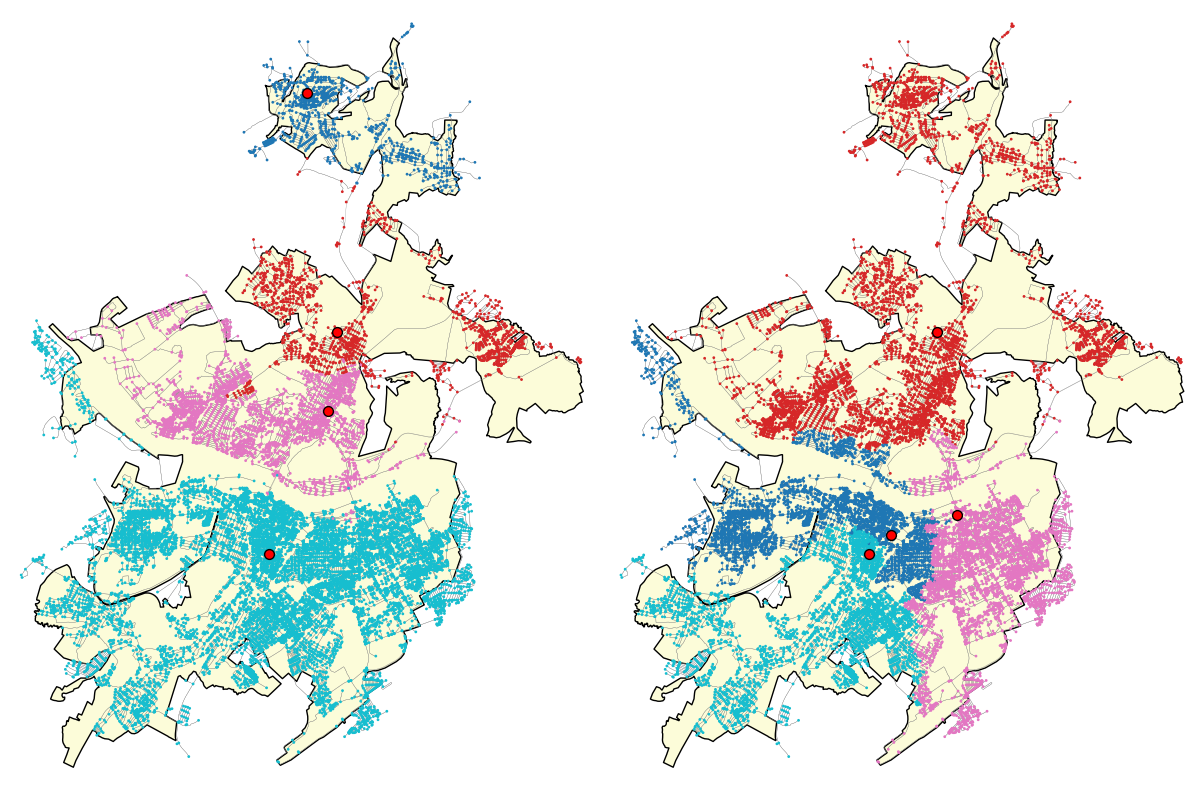

In [83]:
from genesis.point_selectors import RandomNodesSelector

state = FirstArrivalUnitState()
selector = RandomNodesSelector()
# Использеум разработанную выше метрику неравномерности нагрузки на ПСЧ
metric = StdIndex()

# Инициализация алгоритма
mclp = BestNodesGA2(
    state_function     = state,
    metric_function    = metric,
    node_selector      = selector,
    population_size    = 50,
    epochs             = 15,
    mutation_max_count = 2,
    epoch_end_function = lambda epoch, best_metric, **kwargs: print(f"Эпоха: {epoch}, Лучшее значение метрики: {best_metric}")
)

# Формированеи стартовой дислокации
g_nodes_list = list(G.nodes())
start_points = {
    g_nodes_list[1000]: 'псч 1',
    g_nodes_list[2000]: 'псч 2',
    g_nodes_list[3000]: 'псч 3',
    g_nodes_list[4000]: 'псч 4',
}
# Запуск алгоритма
best_nodes, best_metric = mclp(
    env           = G,
    dynamic_nodes = start_points)



# Анализ исходной дислокации
times, nearest = state(env=G, points=start_points)
# Анализ полученной дислокации
times1, nearest1 = state(env=G, points=best_nodes)

print(f"Исходная неравномерность нагрузки на ПСЧ:               {metric(nearest)}")
print(f"Полученная неравномерность нагрузки на ПСЧ:             {metric(nearest1)}")
print(f"Исходное среднее время прибытия в любую точку города:   {ArrivalTime()(times)}")
print(f"Полученное среднее время прибытия в любую точку города: {ArrivalTime()(times1)}")

# Печать результатов
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes = g_nodes.merge(nearest, left_index=True, right_index=True)
g_nodes1 = ox.graph_to_gdfs(G, edges=False)
g_nodes1 = g_nodes1.merge(nearest1, left_index=True, right_index=True)
# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта исходного распределения
borders.plot(ax=ax1, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
g_nodes.plot(ax=ax1, column='nearest', markersize=1) 
g_nodes.loc[start_points.keys()].plot(ax=ax1, facecolors='r', edgecolors='k', markersize=50)

# Карта итогового распределения
borders.plot(ax=ax2, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
g_nodes1.plot(ax=ax2, column='nearest', markersize=1) 
g_nodes1.loc[best_nodes.keys()].plot(ax=ax2, facecolors='r', edgecolors='k', markersize=50)

plt.show()